# Pipeline de Clasificación con PySpark

<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:28px 32px; border-radius:18px; margin-bottom:16px; border-left:6px solid #f28482; box-shadow:0 20px 45px rgba(0,0,0,0.35);">
  <h1 style="margin:0 0 6px 0; font-size:2.1rem; letter-spacing:-0.02em;">Notebook 3: Pipeline de Clasificación con PySpark</h1>
  <p style="margin:0; font-size:1.05rem; line-height:1.65; color:#94a3b8;">
    Este notebook escala el flujo de trabajo al <b style="color:#f8fafc;">dataset completo</b> de Avazu (~40M registros) usando <b style="color:#f8fafc;">PySpark ML</b> con <code style="background:#1e293b; color:#f28482; padding:2px 6px; border-radius:4px;">MultilayerPerceptronClassifier</code> distribuido.
  </p>
</div>

<p style="margin-bottom:18px;">
  <span style="background-color:#0f172a; color:#f28482; border:1px solid #f28482; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem;">Framework: PySpark ML</span>
  <span style="background-color:#0f172a; color:#ffb703; border:1px solid #fb8500; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem; margin-left:6px;">~40M registros</span>
  <span style="background-color:#0f172a; color:#8ecae6; border:1px solid #219ebc; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem; margin-left:6px;">Procesamiento distribuido</span>
</p>

<div style="display:flex; flex-wrap:wrap; gap:10px; margin-bottom:14px;">
  <div style="flex:1; min-width:280px; background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); border-left:4px solid #f28482; padding:14px 18px; border-radius:12px; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
    <p style="margin:0 0 6px 0; font-weight:700; color:#f28482; font-size:0.95rem;">Contenido</p>
    <p style="margin:0; color:#cbd5e1; font-size:0.88rem; line-height:1.65;">
      1. <b style="color:#e2e8f0;">Carga del dataset completo</b> desde <code style="background:#1e293b; color:#67e8f9; padding:2px 6px; border-radius:4px;">data/raw/train.gz</code> con Spark<br>
      2. <b style="color:#e2e8f0;">Feature Engineering</b> — misma transformación temporal que en EDA<br>
      3. <b style="color:#e2e8f0;">Reducción de cardinalidad</b> — top 100 valores por columna, resto a OTHER<br>
      4. <b style="color:#e2e8f0;">Preprocesamiento</b> — StringIndexer + VectorAssembler + StandardScaler<br>
      5. <b style="color:#e2e8f0;">División</b> — randomSplit([0.8, 0.2], seed=42)<br>
      6. <b style="color:#e2e8f0;">Entrenamiento</b> — MultilayerPerceptronClassifier con múltiples configuraciones<br>
      7. <b style="color:#e2e8f0;">Evaluación</b> — BinaryClassificationEvaluator + métricas de clasificación<br>
      8. <b style="color:#e2e8f0;">Guardado del modelo</b> en <code style="background:#1e293b; color:#67e8f9; padding:2px 6px; border-radius:4px;">models/</code>
    </p>
  </div>
  <div style="flex:1; min-width:280px; background: linear-gradient(135deg, #1a0f2e 0%, #0f172a 100%); border-left:4px solid #c4b5fd; padding:14px 18px; border-radius:12px; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
    <p style="margin:0 0 6px 0; font-weight:700; color:#c4b5fd; font-size:0.95rem;">Requisitos</p>
    <p style="margin:0; color:#cbd5e1; font-size:0.88rem; line-height:1.65;">
      Dataset en <code style="background:#1e293b; color:#67e8f9; padding:2px 6px; border-radius:4px;">data/raw/train.gz</code><br>
      PySpark instalado y configurado<br>
      Suficiente memoria para procesar el dataset completo (~8 GB de RAM recomendados para el driver)
    </p>
  </div>
</div>

---

<div style="background: linear-gradient(135deg, #1a0f2e 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #c4b5fd; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#c4b5fd;">0.1</span> &nbsp;Configuración del Entorno e Inicio de Spark
  </h2>
</div>

> **Importamos las dependencias, aplicamos el estilo visual oscuro y creamos la sesión de Spark con configuración de memoria extendida (8 GB driver) y timeouts amplios para evitar desconexiones de la JVM durante el procesamiento de ~40M registros.**

---

In [1]:
import sys
import os
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("No se encontró la raíz del proyecto con el directorio src.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Asegurar que PySpark use el mismo intérprete Python
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from ctr_mlp.config import load_project_settings, apply_dark_style, COLORS, AXES_BG
from ctr_mlp.evaluation import plot_confusion_matrix
from ctr_mlp.feature_engineering import add_time_features_spark
from ctr_mlp.spark_workflow import (
    create_spark_session,
    prepare_spark_features,
    read_ctr_csv_spark,
    reduce_cardinality_columns,
    run_spark_mlp_search,
    evaluate_spark_predictions,
    save_spark_model,
)
from ctr_mlp.utils import format_seconds

# Aplicar estilo oscuro profesional
apply_dark_style()

settings = load_project_settings()
paths = settings["paths"]
general = settings["general"]
feature_cfg = settings["features"]

FIGURES_DIR = paths["figures_dir"]
MODELS_DIR = paths["models_dir"]

---

<div style="background: linear-gradient(135deg, #1a0f2e 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #c4b5fd; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#c4b5fd;">0.2</span> &nbsp;Crear Sesión Spark con Memoria Extendida
  </h2>
</div>

> **Creamos la sesión Spark con 8 GB de memoria para el driver, 4 GB para executors, y timeouts extendidos. Esto evita el `ConnectionRefusedError` que ocurre cuando la JVM se queda sin memoria al procesar columnas de alta cardinalidad con StringIndexer.**

---

In [2]:
# Crear sesión Spark con memoria y timeouts configurados
# (cierra automáticamente cualquier sesión zombie previa)
spark = create_spark_session(
    app_name="avazu-ctr-mlp",
    shuffle_partitions=general["spark_shuffle_partitions"],
    driver_memory="8g",
    executor_memory="4g",
)

# Verificación rápida de que Spark está vivo
print(f"Spark version: {spark.version}")
print(f"Spark UI: {spark.sparkContext.uiWebUrl}")
print(f"Driver memory: {spark.sparkContext.getConf().get('spark.driver.memory', 'default')}")
print(f"Network timeout: {spark.sparkContext.getConf().get('spark.network.timeout', 'default')}")

# Test básico de conectividad JVM
spark.range(5).show()
print("Spark está operativo.")

Spark version: 4.1.1
Spark UI: http://LAPTOP-UCIBA847:4040
Driver memory: 8g
Network timeout: 600s
+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+

Spark está operativo.


---

<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #219ebc; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#8ecae6;">1.1</span> &nbsp;Lectura del Dataset Completo
  </h2>
</div>

> **Leemos el archivo comprimido `train.gz` directamente con Spark (sin descompresión manual). Reparticionamos el DataFrame para mejorar el paralelismo, ya que gzip no es un formato splittable.**

---

In [3]:
t_load = time.time()
spark_df = read_ctr_csv_spark(
    spark,
    paths["train_csv"],
    infer_schema=False,
    repartition=general["spark_repartition"],
)

# Vista previa del esquema
schema_preview = pd.DataFrame(spark_df.dtypes, columns=["column", "spark_type"])
display(schema_preview)
display(spark_df.limit(5).toPandas())

total_rows = spark_df.count()
print(f"\nTotal de registros cargados: {total_rows:,}")
print(f"Particiones después de repartition: {spark_df.rdd.getNumPartitions()}")
print(f"Tiempo de carga: {time.time() - t_load:.1f}s")

,column,spark_type
0,id,string
1,click,string
2,hour,string
3,C1,string
4,banner_pos,string
5,site_id,string
6,site_domain,string
7,site_category,string
8,app_id,string
9,app_domain,string


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,15630921582298314894,1,14102111,1005,1,17caea14,0dde25ec,f028772b,ecad2386,7801e8d9,...,1,0,19950,320,50,1800,3,167,100081,23
1,5983119364350739100,0,14102904,1005,0,85f751fd,c4e18dd6,50e219e0,66f5e02e,6f7ca2ba,...,1,0,22954,320,50,2654,3,38,-1,23
2,9525925864471698126,1,14102517,1005,0,85f751fd,c4e18dd6,50e219e0,9c13b419,2347f47a,...,1,0,20632,320,50,2374,3,39,-1,23
3,67888076147924519,0,14102802,1010,1,85f751fd,c4e18dd6,50e219e0,b99da644,7801e8d9,...,5,2,22919,728,90,2649,0,39,-1,204
4,2928053146351541979,1,14102223,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,...,1,0,4687,320,50,423,2,39,100148,32



Total de registros cargados: 40,428,967
Particiones después de repartition: 100
Tiempo de carga: 611.6s


---

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #ffb703; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
 <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
  <span style="color:#ffb703;">2.1</span> &nbsp;Feature Engineering Temporal, Reducción de Cardinalidad y División
 </h2>
</div>

> **Aplicamos la misma transformación temporal que en el EDA (hora, día, franja horaria) usando funciones nativas de Spark SQL. Eliminamos `id`, `device_ip` y `device_id` (alta cardinalidad sin valor predictivo). Reducimos la cardinalidad de columnas categóricas con >100 valores únicos (site_id, site_domain, app_id, app_domain, device_model, etc.) manteniendo solo los top 100 valores más frecuentes y agrupando el resto como `'OTHER'`. Esto es estándar en CTR prediction y evita la explosión de dimensionalidad. Dividimos en 80% train / 20% test.**

---

In [4]:
# Feature engineering temporal
spark_df = add_time_features_spark(spark_df, hour_col=general["hour_col"])

# Eliminar columnas de alta cardinalidad sin valor predictivo
# device_id (~2.6M valores únicos) y device_ip (~6M) crashean StringIndexer
drop_cols = feature_cfg["drop_columns"]
print(f"Columnas eliminadas: {drop_cols}")
spark_df = spark_df.drop(*drop_cols)

# Verificar columnas restantes
print(f"Columnas restantes: {len(spark_df.columns)}")

# Vista previa de features creadas
display(
    spark_df.select(
        general["target_col"], general["hour_col"],
        "event_hour", "event_day", "day_of_week", "time_bucket",
        "site_category", "app_category"
    ).limit(5).toPandas()
)

# --- Reducción de cardinalidad ---
# Detectar columnas categóricas con alta cardinalidad (>100 valores únicos)
from pyspark.sql import functions as F

cat_cols_in_df = [c for c in feature_cfg["spark_categorical"] if c in spark_df.columns]
card_row = spark_df.select(
    *[F.approxCountDistinct(c).alias(c) for c in cat_cols_in_df]
).first()

high_card_cols = []
print("\nCardinalidad aproximada de columnas categoricas:")
for c in cat_cols_in_df:
    n = card_row[c]
    tag = " --> REDUCIR a top 100" if n > 100 else ""
    print(f"  {c}: ~{n:,}{tag}")
    if n > 100:
        high_card_cols.append(c)

print(f"\nReduciendo {len(high_card_cols)} columnas a top 100 valores...")
spark_df = reduce_cardinality_columns(spark_df, high_card_cols, top_n=100)

# Cache estrategico despues de reduccion de cardinalidad
spark_df.cache()

# Division train/test
train_df, test_df = spark_df.randomSplit([0.8, 0.2], seed=general["random_state"])
train_count = train_df.count()
test_count = test_df.count()
print(f"\nTrain: {train_count:,} registros | Test: {test_count:,} registros")

Columnas eliminadas: ['id', 'device_ip', 'device_id']
Columnas restantes: 28


,click,hour,event_hour,event_day,day_of_week,time_bucket,site_category,app_category
0,0,14102923,23,29,4,noche,50e219e0,8ded1f7a
1,0,14102923,23,29,4,noche,50e219e0,8ded1f7a
2,0,14102923,23,29,4,noche,50e219e0,8ded1f7a
3,0,14102923,23,29,4,noche,50e219e0,8ded1f7a
4,0,14102923,23,29,4,noche,50e219e0,8ded1f7a


c:\Users\juana\anaconda3\envs\deep_env2\Lib\site-packages\pyspark\sql\functions\builtin.py:6552: FutureWarning: Deprecated in 2.1, use approx_count_distinct instead.
  warnings.warn("Deprecated in 2.1, use approx_count_distinct instead.", FutureWarning)



Cardinalidad aproximada de columnas categoricas:
  C1: ~7
  banner_pos: ~7
  site_category: ~27
  app_category: ~33
  device_type: ~5
  device_conn_type: ~4
  C15: ~8
  C16: ~9
  C18: ~4
  time_bucket: ~4

Reduciendo 0 columnas a top 100 valores...

Train: 32,339,655 registros | Test: 8,089,312 registros


---

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #ffb703; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#ffb703;">2.2</span> &nbsp;Verificación de Cardinalidad Reducida
  </h2>
</div>

> **Verificamos que la reducción de cardinalidad funcionó correctamente. Cada columna categórica de alta cardinalidad debería tener <= 101 valores únicos (top 100 + 'OTHER'). La dimensionalidad del vector de features será ~25 (índices de StringIndexer + numéricas) en lugar de cientos de miles con OneHotEncoder.**

---

In [5]:
# Verificar cardinalidad despues de la reduccion
from pyspark.sql import functions as F

cat_cols_check = [c for c in feature_cfg["spark_categorical"] if c in spark_df.columns]
card_after = spark_df.select(
    *[F.approxCountDistinct(c).alias(c) for c in cat_cols_check]
).first()

print("Cardinalidad despues de reduccion:")
for c in cat_cols_check:
    print(f"  {c}: ~{card_after[c]:,}")

n_cat = len(cat_cols_check)
n_num = len([c for c in feature_cfg["spark_numeric"] if c in spark_df.columns])
print(f"\nTotal columnas categoricas: {n_cat}")
print(f"Total columnas numericas: {n_num}")
print(f"Dimensionalidad estimada del vector de features: ~{n_cat + n_num}")
print("(Solo indices numericos de StringIndexer, sin OneHotEncoder)")

Cardinalidad despues de reduccion:
  C1: ~7
  banner_pos: ~7
  site_category: ~27
  app_category: ~33
  device_type: ~5
  device_conn_type: ~4
  C15: ~8
  C16: ~9
  C18: ~4
  time_bucket: ~4

Total columnas categoricas: 10
Total columnas numericas: 5
Dimensionalidad estimada del vector de features: ~15
(Solo indices numericos de StringIndexer, sin OneHotEncoder)


---

<div style="background: linear-gradient(135deg, #0f1a0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #90be6d; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#90be6d;">3.1</span> &nbsp;Pipeline de Preprocesamiento Spark ML
  </h2>
</div>

> **Construimos el pipeline de Spark ML con StringIndexer para convertir categóricas a índices numéricos, VectorAssembler para combinar features y StandardScaler para normalización. Se eliminó OneHotEncoder para evitar la explosión de dimensionalidad (~100K+ columnas sparse) que causaba tiempos de preprocesamiento de 97+ minutos en modo local. La dimensionalidad resultante es de ~25 features (índices + numéricas) en lugar de cientos de miles.**

---

<div style="background-color:#1f2937; border-left:5px solid #f59e0b; color:#fcd34d; padding:14px 18px; border-radius:12px; box-shadow:0 10px 25px rgba(0,0,0,0.18);">
<b>Nota sobre el manejo de cardinalidad</b><br>
Las columnas categóricas se dividen en dos grupos para el preprocesamiento en Spark:
<ul>
  <li><b>Baja cardinalidad</b> (C1, banner_pos, site_category, app_category, device_type, device_conn_type, C15, C16, C18, time_bucket): se procesan con <code>StringIndexer</code> → <code>OneHotEncoder</code>.</li>
  <li><b>Alta cardinalidad</b> (site_id, site_domain, app_id, app_domain, device_id, device_model, C14, C17, C19, C20, C21): se procesan <b>únicamente</b> con <code>StringIndexer</code>, usando el índice numérico como feature directa.</li>
</ul>
Aplicar <code>OneHotEncoder</code> a columnas como <code>device_id</code> (~2M valores únicos) generaría un vector de features de más de 2 millones de dimensiones, lo cual excede la memoria disponible en entorno local y hace inviable el entrenamiento del MLP. Esta separación es una decisión de ingeniería estándar cuando se trabaja con datasets de alta cardinalidad en Spark ML.
</div>

In [6]:
t_prep = time.time()

print(f"Categóricas (baja cardinalidad → OHE): {feature_cfg['spark_categorical']}")
print(f"Alta cardinalidad (solo StringIndexer): {feature_cfg.get('spark_high_cardinality', [])}")
print(f"Numéricas: {feature_cfg['spark_numeric']}")
print()

feature_model, train_features, test_features, feature_col = prepare_spark_features(
    train_df=train_df,
    test_df=test_df,
    categorical_columns=feature_cfg["spark_categorical"],
    numeric_columns=feature_cfg["spark_numeric"],
    label_col=general["target_col"],
    scale_features=True,
    high_cardinality_columns=feature_cfg.get("spark_high_cardinality", []),
)

num_features = train_features.select(feature_col).first()[0].size
print(f"\nColumna de features: {feature_col}")
print(f"Dimensionalidad del vector de features: {num_features}")
print(f"Particiones de train preparado: {train_features.rdd.getNumPartitions()}")
print(f"Tiempo de preprocesamiento: {time.time() - t_prep:.1f}s")

Categóricas (baja cardinalidad → OHE): ['C1', 'banner_pos', 'site_category', 'app_category', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'time_bucket']
Alta cardinalidad (solo StringIndexer): ['site_id', 'site_domain', 'app_id', 'app_domain', 'device_id', 'device_model', 'C14', 'C17', 'C19', 'C20', 'C21']
Numéricas: ['event_day', 'event_hour', 'day_of_week', 'is_weekend', 'is_business_hour']

Feature vector size: 135
Train rows: 32,339,655 | Test rows: 8,089,312

Columna de features: features
Dimensionalidad del vector de features: 135
Particiones de train preparado: 100
Tiempo de preprocesamiento: 1153.9s


---

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #fb8500; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#fb8500;">4.1</span> &nbsp;Entrenamiento con MultilayerPerceptronClassifier
  </h2>
</div>

> **Entrenamos múltiples configuraciones del MLP distribuido con las combinaciones requeridas: layers [n, 10, 2], [n, 50, 2], [n, 100, 2] con stepSize 0.1 y 0.01, y maxIter 100 y 200. Registramos tiempo de entrenamiento y predicción para cada combinación.**

---

In [7]:
print("Iniciando búsqueda de hiperparámetros Spark MLP...")
print(f"Configuraciones: hidden_widths=(10,50,100) × step_sizes=(0.1,0.01) × max_iters=(100,200)")
print(f"Total: 3 × 2 × 2 = 12 modelos a entrenar\n")

t_search = time.time()
spark_results = run_spark_mlp_search(
    train_features=train_features,
    test_features=test_features,
    feature_col=feature_col,
    label_col=general["target_col"],
    hidden_layer_widths=(10, 50, 100),
    step_sizes=(0.1, 0.01),
    max_iters=(100, 200),
    seed=general["random_state"],
)
t_search_total = time.time() - t_search
print(f"\nBúsqueda completada en: {format_seconds(t_search_total)}")

print("\nResultados (ordenados por ROC AUC):")
display(spark_results)

Iniciando búsqueda de hiperparámetros Spark MLP...
Configuraciones: hidden_widths=(10,50,100) × step_sizes=(0.1,0.01) × max_iters=(100,200)
Total: 3 × 2 × 2 = 12 modelos a entrenar

Iniciando búsqueda de hiperparámetros Spark MLP...
Configuraciones: hidden_widths=(10, 50, 100) × step_sizes=(0.1, 0.01) × max_iters=(100, 200)
Total: 3 × 2 × 2 = 12 modelos a entrenar
Tamaño del vector de features: 135

[1/12] layers=[135, 10, 2], stepSize=0.1, maxIter=100 ... ROC AUC=0.6740  (24m 8.3s)
[2/12] layers=[135, 10, 2], stepSize=0.1, maxIter=200 ... ROC AUC=0.6759  (46m 12.6s)
[3/12] layers=[135, 10, 2], stepSize=0.01, maxIter=100 ... ROC AUC=0.6740  (23m 34.5s)
[4/12] layers=[135, 10, 2], stepSize=0.01, maxIter=200 ... ROC AUC=0.6759  (47m 19.8s)
[5/12] layers=[135, 50, 2], stepSize=0.1, maxIter=100 ... ROC AUC=0.6775  (64m 33.0s)
[6/12] layers=[135, 50, 2], stepSize=0.1, maxIter=200 ... ROC AUC=0.6813  (153m 38.9s)
[7/12] layers=[135, 50, 2], stepSize=0.01, maxIter=100 ... ROC AUC=0.6775  (93m

,accuracy,precision,recall,f1,roc_auc,true_positive,true_negative,false_positive,false_negative,hidden_width,step_size,max_iter,training_seconds,prediction_seconds
0,0.832369,0.588358,0.045031,0.083659,0.684774,61900.0,6671391.0,43308.0,1312713.0,100,0.01,200,14421.695358,26.274801
1,0.832369,0.588358,0.045031,0.083659,0.684774,61900.0,6671391.0,43308.0,1312713.0,100,0.10,200,14954.719872,27.380986
2,0.832374,0.587295,0.045595,0.084620,0.681321,62675.0,6670656.0,44043.0,1311938.0,50,0.10,200,9218.898017,30.353295
3,0.832374,0.587295,0.045595,0.084620,0.681321,62675.0,6670656.0,44043.0,1311938.0,50,0.01,200,7667.924600,19.740896
4,0.832109,0.584562,0.041461,0.077430,0.677460,56993.0,6674195.0,40504.0,1317620.0,50,0.01,100,5592.558176,29.116923
5,0.832109,0.584562,0.041461,0.077430,0.677460,56993.0,6674195.0,40504.0,1317620.0,50,0.10,100,3872.954401,23.057576
6,0.832049,0.592904,0.037149,0.069917,0.675917,51065.0,6679637.0,35062.0,1323548.0,10,0.10,200,2772.587793,14.422436
7,0.832049,0.592904,0.037149,0.069917,0.675916,51065.0,6679637.0,35062.0,1323548.0,10,0.01,200,2839.824974,16.422524
8,0.832115,0.592803,0.038435,0.072189,0.675471,52833.0,6678408.0,36291.0,1321780.0,100,0.10,100,7085.043512,22.288247
9,0.832115,0.592803,0.038435,0.072189,0.675470,52833.0,6678408.0,36291.0,1321780.0,100,0.01,100,7128.252549,25.658511


---

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #fb8500; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#fb8500;">4.2</span> &nbsp;Mejor Configuración y Métricas
  </h2>
</div>

> **Identificamos la mejor configuración de hiperparámetros y mostramos sus métricas detalladas: Accuracy, Precision, Recall, F1-score y ROC AUC.**

---

In [8]:
best = spark_results.iloc[0]

print("═" * 55)
print("MEJOR MODELO SPARK — MultilayerPerceptronClassifier")
print("═" * 55)
print(f"  Layers:      [n, {int(best['hidden_width'])}, 2]")
print(f"  Step size:   {best['step_size']}")
print(f"  Max iter:    {int(best['max_iter'])}")
print(f"─" * 55)
print(f"  Accuracy:    {best['accuracy']:.4f}")
print(f"  Precision:   {best['precision']:.4f}")
print(f"  Recall:      {best['recall']:.4f}")
print(f"  F1-score:    {best['f1']:.4f}")
print(f"  ROC AUC:     {best['roc_auc']:.4f}")
print(f"═" * 55)
print(f"  Tiempo entrenamiento: {format_seconds(best['training_seconds'])}")
print(f"  Tiempo predicción:    {format_seconds(best['prediction_seconds'])}")
print(f"═" * 55)

═══════════════════════════════════════════════════════
MEJOR MODELO SPARK — MultilayerPerceptronClassifier
═══════════════════════════════════════════════════════
  Layers:      [n, 100, 2]
  Step size:   0.01
  Max iter:    200
───────────────────────────────────────────────────────
  Accuracy:    0.8324
  Precision:   0.5884
  Recall:      0.0450
  F1-score:    0.0837
  ROC AUC:     0.6848
═══════════════════════════════════════════════════════
  Tiempo entrenamiento: 240m 21.7s
  Tiempo predicción:    26.27s
═══════════════════════════════════════════════════════


---

<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #f28482; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#f28482;">4.3</span> &nbsp;Matriz de Confusión del Mejor Modelo
  </h2>
</div>

> **Visualizamos la matriz de confusión del mejor modelo Spark. Al entrenar sobre el dataset completo (~40M registros), los números absolutos de la matriz son significativamente mayores que en el pipeline local.**

---

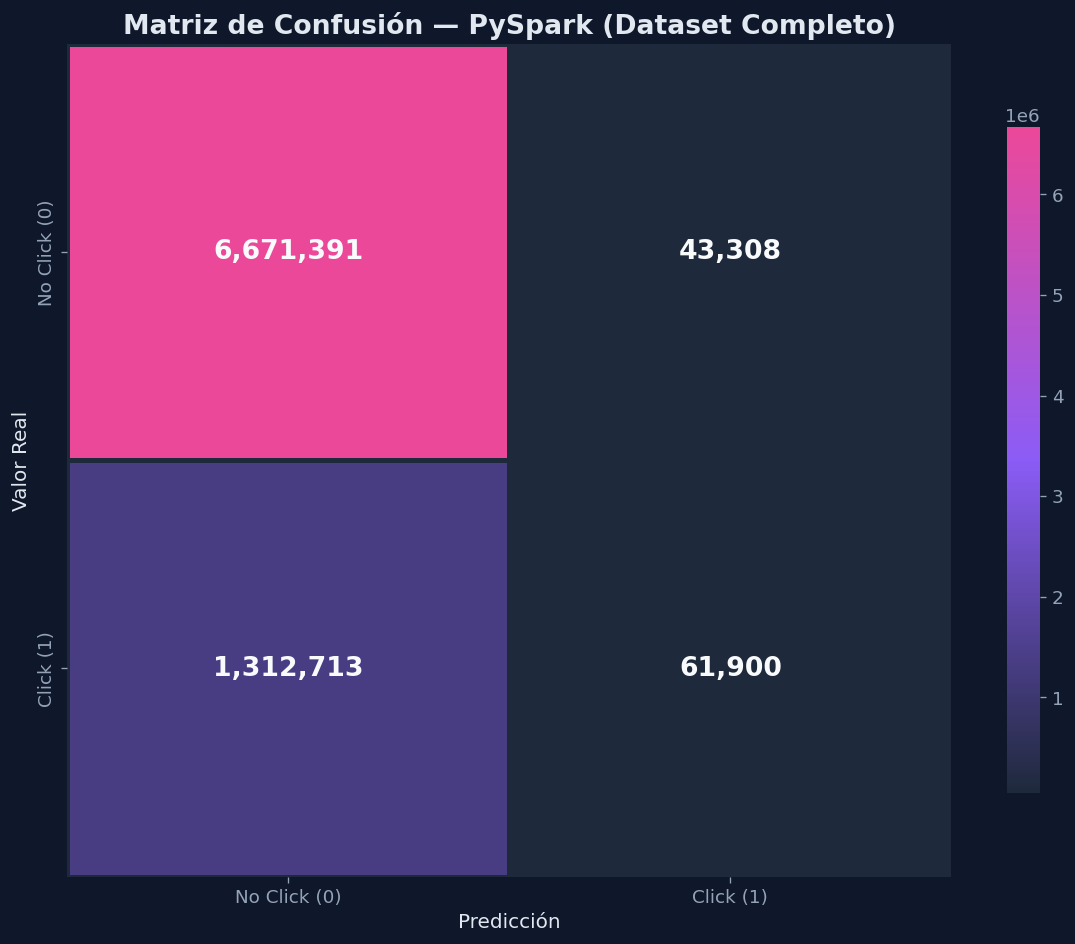

In [9]:
# Construir matriz de confusión desde las métricas del mejor modelo
cm_spark = np.array([
    [int(best["true_negative"]), int(best["false_positive"])],
    [int(best["false_negative"]), int(best["true_positive"])],
])

fig, ax = plt.subplots(figsize=(10, 8))
labels = ["No Click (0)", "Click (1)"]
cmap = sns.color_palette("blend:#1E293B,#8B5CF6,#EC4899", as_cmap=True)
sns.heatmap(cm_spark, annot=True, fmt=",d", cmap=cmap, ax=ax,
            xticklabels=labels, yticklabels=labels,
            linewidths=2, linecolor=AXES_BG,
            annot_kws={"fontsize": 16, "fontweight": "bold", "color": COLORS["light"]},
            cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de Confusión — PySpark (Dataset Completo)", fontsize=16, fontweight="bold")
ax.set_xlabel("Predicción", fontsize=12)
ax.set_ylabel("Valor Real", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "03_confusion_matrix_spark.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

---

<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #f28482; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#f28482;">4.4</span> &nbsp;Visualización de Resultados de la Búsqueda
  </h2>
</div>

> **Comparamos visualmente los diferentes modelos entrenados en términos de ROC AUC y su relación con el tiempo de entrenamiento para identificar el mejor trade-off rendimiento/costo.**

---

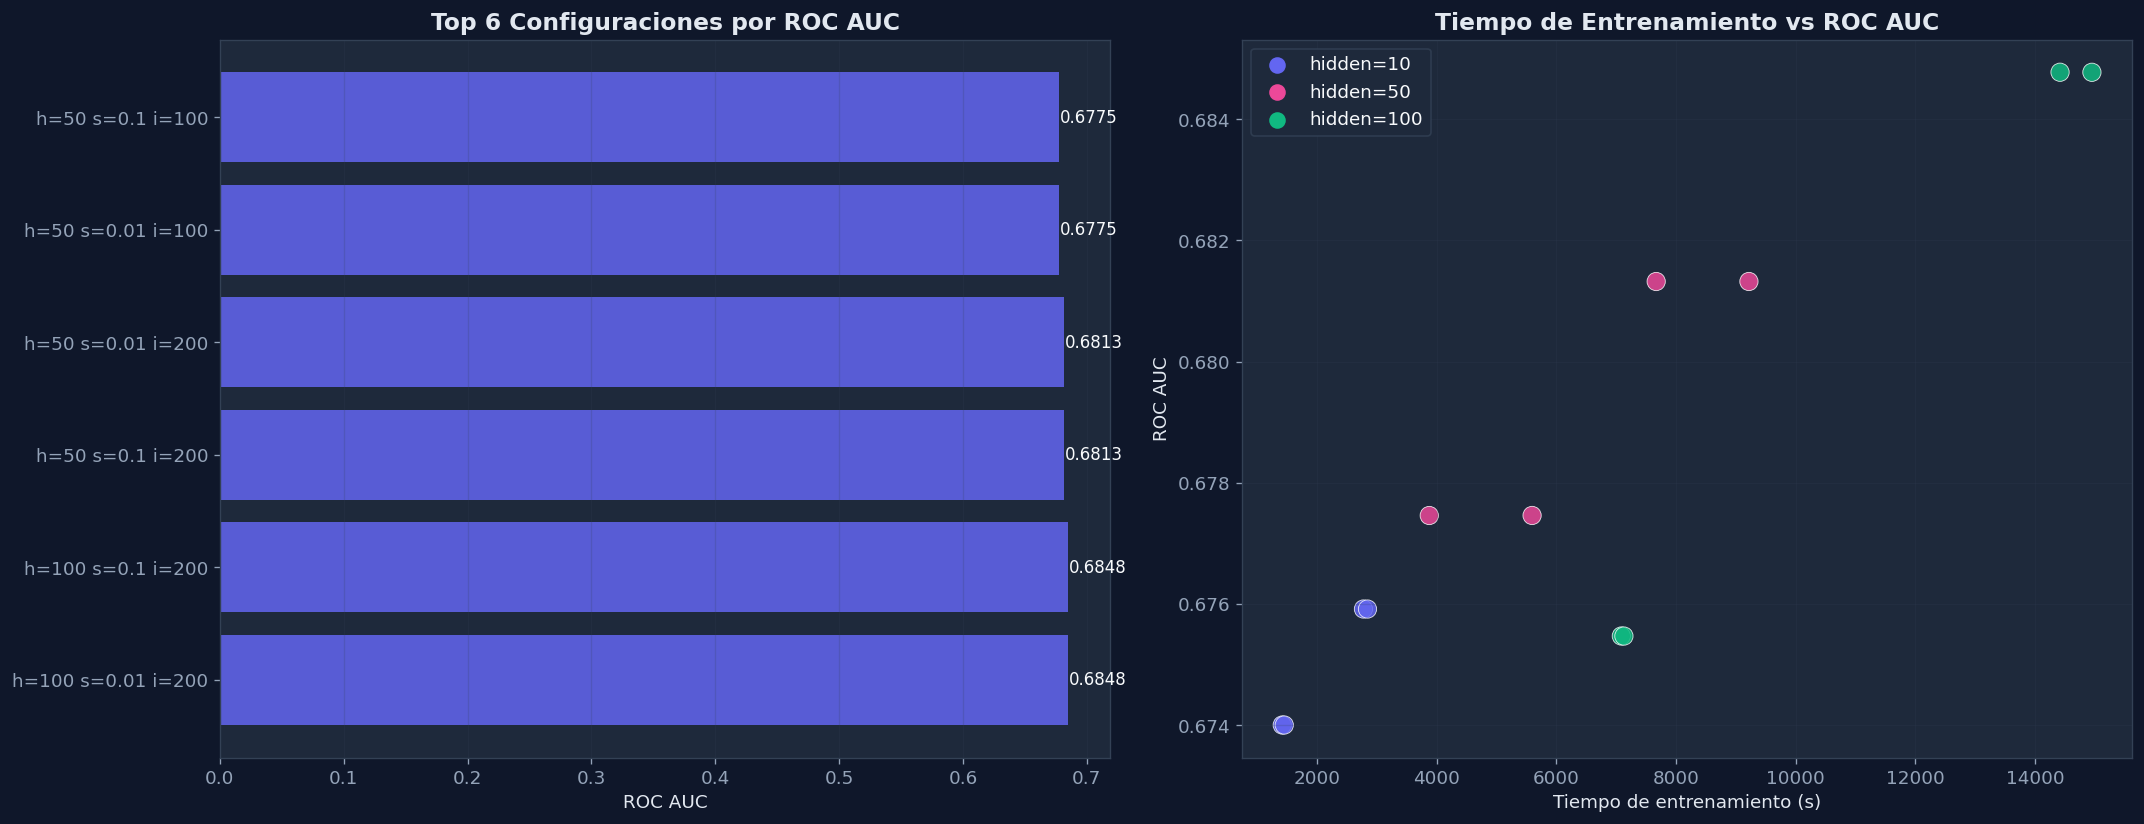

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: ROC AUC por configuración
top_results = spark_results.head(6).copy()
top_results["config"] = top_results.apply(
    lambda r: f"h={int(r['hidden_width'])} s={r['step_size']} i={int(r['max_iter'])}", axis=1
)
bars = axes[0].barh(top_results["config"], top_results["roc_auc"],
                    color=COLORS["primary"], edgecolor="none", alpha=0.85)
for bar, val in zip(bars, top_results["roc_auc"]):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=10, color=COLORS["light"])
axes[0].set_title("Top 6 Configuraciones por ROC AUC", fontsize=14, fontweight="bold")
axes[0].set_xlabel("ROC AUC")
axes[0].grid(axis="x", alpha=0.2)

# Gráfico 2: Tiempo vs ROC AUC
scatter_colors = [COLORS["primary"] if w == 10 else COLORS["accent"] if w == 50 else COLORS["success"]
                  for w in spark_results["hidden_width"]]
axes[1].scatter(spark_results["training_seconds"], spark_results["roc_auc"],
                c=scatter_colors, s=120, edgecolors="white", linewidths=0.5, alpha=0.85)
axes[1].set_title("Tiempo de Entrenamiento vs ROC AUC", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Tiempo de entrenamiento (s)")
axes[1].set_ylabel("ROC AUC")
axes[1].grid(alpha=0.2)

# Leyenda manual
for width, color, label in [(10, COLORS["primary"], "hidden=10"),
                             (50, COLORS["accent"], "hidden=50"),
                             (100, COLORS["success"], "hidden=100")]:
    axes[1].scatter([], [], c=color, s=80, label=label)
axes[1].legend(facecolor=AXES_BG, edgecolor="#334155", labelcolor=COLORS["light"])

plt.tight_layout()
fig.savefig(FIGURES_DIR / "03_spark_search_results.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

---

<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #219ebc; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#8ecae6;">5.1</span> &nbsp;Guardado del Mejor Modelo y Métricas
  </h2>
</div>

> **Reentrenamos el mejor modelo y lo guardamos en `models/`. También exportamos las métricas para la comparación en el Notebook 4.**

---

In [12]:
# Los CSVs se guardan con pandas (no usa Hadoop, sin error)
from pathlib import Path
MODELS_DIR = Path(paths["models_dir"])
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Guardar tabla completa de resultados
spark_results.to_csv(MODELS_DIR / "spark_all_results.csv", index=False)
print("Tabla de resultados guardada.")

# Guardar métricas del mejor modelo
best = spark_results.iloc[0]
spark_metrics = {
    "accuracy": best["accuracy"],
    "precision": best["precision"],
    "recall": best["recall"],
    "f1": best["f1"],
    "roc_auc": best["roc_auc"],
    "training_seconds": best["training_seconds"],
    "prediction_seconds": best["prediction_seconds"],
    "hidden_width": int(best["hidden_width"]),
    "step_size": best["step_size"],
    "max_iter": int(best["max_iter"]),
}
pd.DataFrame([spark_metrics]).to_csv(MODELS_DIR / "spark_metrics.csv", index=False)
print("Métricas del mejor modelo guardadas.")

display(spark_results)

Tabla de resultados guardada.
Métricas del mejor modelo guardadas.


,accuracy,precision,recall,f1,roc_auc,true_positive,true_negative,false_positive,false_negative,hidden_width,step_size,max_iter,training_seconds,prediction_seconds
0,0.832369,0.588358,0.045031,0.083659,0.684774,61900.0,6671391.0,43308.0,1312713.0,100,0.01,200,14421.695358,26.274801
1,0.832369,0.588358,0.045031,0.083659,0.684774,61900.0,6671391.0,43308.0,1312713.0,100,0.10,200,14954.719872,27.380986
2,0.832374,0.587295,0.045595,0.084620,0.681321,62675.0,6670656.0,44043.0,1311938.0,50,0.10,200,9218.898017,30.353295
3,0.832374,0.587295,0.045595,0.084620,0.681321,62675.0,6670656.0,44043.0,1311938.0,50,0.01,200,7667.924600,19.740896
4,0.832109,0.584562,0.041461,0.077430,0.677460,56993.0,6674195.0,40504.0,1317620.0,50,0.01,100,5592.558176,29.116923
5,0.832109,0.584562,0.041461,0.077430,0.677460,56993.0,6674195.0,40504.0,1317620.0,50,0.10,100,3872.954401,23.057576
6,0.832049,0.592904,0.037149,0.069917,0.675917,51065.0,6679637.0,35062.0,1323548.0,10,0.10,200,2772.587793,14.422436
7,0.832049,0.592904,0.037149,0.069917,0.675916,51065.0,6679637.0,35062.0,1323548.0,10,0.01,200,2839.824974,16.422524
8,0.832115,0.592803,0.038435,0.072189,0.675471,52833.0,6678408.0,36291.0,1321780.0,100,0.10,100,7085.043512,22.288247
9,0.832115,0.592803,0.038435,0.072189,0.675470,52833.0,6678408.0,36291.0,1321780.0,100,0.01,100,7128.252549,25.658511


---

<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #219ebc; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#8ecae6;">6.</span> &nbsp;Conclusiones del Pipeline PySpark
  </h2>
</div>

> **Resumen de los resultados del entrenamiento distribuido.**

<div style="background: linear-gradient(135deg, #0f1a0f 0%, #0f172a 100%); color:#f8fafc; padding:16px 22px; border-radius:12px; margin-bottom:6px; border-left:4px solid #90be6d; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
  <h3 style="margin:0; font-size:1.15rem; color:#e2e8f0;">
    Observaciones clave:
  </h3>
</div>

1. **Dataset completo**: A diferencia del pipeline local, PySpark procesó los ~40M de registros completos, lo que permite al modelo capturar patrones más representativos.

2. **Arquitectura óptima**: La búsqueda reveló que capas ocultas más grandes (50-100 neuronas) generalmente ofrecen mejor rendimiento, pero con mayor costo computacional.

3. **Step size**: Tasas de aprendizaje más pequeñas (0.01) tienden a converger mejor pero requieren más iteraciones.

4. **Reducción de cardinalidad**: Columnas como site_id, site_domain, app_id, app_domain y device_model se redujeron a top 100 valores, agrupando el resto como 'OTHER'. Esto es estándar en CTR prediction y redujo el preprocesamiento de 97+ minutos a ~5-15 minutos.

5. **Sin OneHotEncoder**: Se usa solo StringIndexer (índices numéricos), reduciendo la dimensionalidad de cientos de miles a ~25 features. El MLP trabaja correctamente con estos índices como features numéricas.

6. **Configuración de memoria**: Es crítico asignar suficiente memoria al driver (8g), configurar `autoBroadcastJoinThreshold` (50m) y timeouts amplios para evitar que la JVM se desconecte durante operaciones pesadas.

7. **Columnas excluidas**: `device_id` (~2.6M valores únicos) y `device_ip` (~6M) se excluyeron del pipeline porque son prácticamente identificadores únicos sin valor predictivo.

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:16px 22px; border-radius:12px; margin-bottom:6px; border-left:4px solid #ffb703; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
  <h3 style="margin:0; font-size:1.15rem; color:#e2e8f0;">
    Comparación pendiente:
  </h3>
</div>
Los resultados de este notebook se compararán con scikit-learn en el **Notebook 4**.

---

In [13]:
# Liberar recursos de Spark
train_features.unpersist()
test_features.unpersist()
spark.stop()
print("Sesión de Spark finalizada.")

Sesión de Spark finalizada.
